# Solve surface volatiles according to outgassing+chemistry

Demonstrates how MMW and total surface pressure change both as a function of Hppmw and fO2. 

In [1]:
import matplotlib as mpl
mpl.rcParams.update({'font.size': 12})
mpl.rcParams['axes.formatter.useoffset'] = False

from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from cmcrameri import cm

from calliope.solve import *
from calliope.structure import calculate_mantle_mass
from calliope.constants import R_earth, const_G, M_earth, ocean_moles, R_gas

from proteus.utils.plot import latexify

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
# %matplotlib widget

In [3]:
M_ocean = ocean_moles * 18.01528 / 1000  # kg

### Set up initial options dict

In [4]:
OPTIONS = {}

OPTIONS['Phi_global'] = 0.40
OPTIONS['T_magma'] = 1630.0
OPTIONS['fO2_shift_IW'] = -3.0
OPTIONS['planet_coresize'] = 0.35
OPTIONS['radius'] = R_earth * 1.273
OPTIONS['mass']   = M_earth * 3.0
OPTIONS['NH_ratio'] = 0.0
OPTIONS['SH_ratio'] = 0.8
OPTIONS['CH_ratio'] = 0.1

H_ppmw  = 1e4

OPTIONS['gravity'] = const_G * OPTIONS['mass'] / (OPTIONS['radius']**2)

def set_composition(OPTIONS, H_ppmw):

    M_m = calculate_mantle_mass(OPTIONS["radius"], OPTIONS["mass"], OPTIONS["planet_coresize"])

    OPTIONS['hydrogen_ppmw'] = H_ppmw
    OPTIONS['hydrogen_earth_oceans'] = M_m * OPTIONS['hydrogen_ppmw'] / 1e6 / M_ocean
    OPTIONS['nitrogen_ppmw'] = OPTIONS['NH_ratio'] * OPTIONS['hydrogen_ppmw']
    OPTIONS['sulfur_ppmw'] = OPTIONS['SH_ratio'] * OPTIONS['hydrogen_ppmw']
    
    return OPTIONS

OPTIONS = set_composition(OPTIONS, H_ppmw)

solvevol_vols = ['H2O', 'CO2', 'N2', 'H2', 'CO', 'CH4', 'S2', 'SO2', 'H2S', 'NH3']
for v in solvevol_vols:
    OPTIONS[v+"_included"] = 0
    OPTIONS[v+"_initial_bar"] = 0.0

OPTIONS["H2O_included"] = 1
OPTIONS["CO2_included"] = 1
OPTIONS["N2_included"]  = 1
OPTIONS["S2_included"]  = 1

OPTIONS["H2_included"]  = 1
OPTIONS["CO_included"]  = 1
OPTIONS["CH4_included"] = 1
OPTIONS["SO2_included"] = 1
OPTIONS["H2S_included"] = 1
OPTIONS["NH3_included"] = 0
OPTIONS["O2_included"] = 1

print("Gravity = %.3f m.s-2" % OPTIONS["gravity"])

Gravity = 18.384 m.s-2


### Calculate total amount of each element in the system

In [5]:
OPTIONS["M_mantle"] = calculate_mantle_mass(OPTIONS["radius"], OPTIONS["mass"], OPTIONS["planet_coresize"])
BACKUP_options = deepcopy(OPTIONS)

print("Options:")
for k in OPTIONS.keys():
    print("  %s = %s" % (k, OPTIONS[k]))

Options:
  Phi_global = 0.4
  T_magma = 1630.0
  fO2_shift_IW = -3.0
  planet_coresize = 0.35
  radius = 8065013.846999999
  mass = 1.7916e+25
  NH_ratio = 0.0
  SH_ratio = 0.8
  CH_ratio = 0.1
  gravity = 18.383798081019247
  hydrogen_ppmw = 10000.0
  hydrogen_earth_oceans = 121.89107430391074
  nitrogen_ppmw = 0.0
  sulfur_ppmw = 8000.0
  H2O_included = 1
  H2O_initial_bar = 0.0
  CO2_included = 1
  CO2_initial_bar = 0.0
  N2_included = 1
  N2_initial_bar = 0.0
  H2_included = 1
  H2_initial_bar = 0.0
  CO_included = 1
  CO_initial_bar = 0.0
  CH4_included = 1
  CH4_initial_bar = 0.0
  S2_included = 1
  S2_initial_bar = 0.0
  SO2_included = 1
  SO2_initial_bar = 0.0
  H2S_included = 1
  H2S_initial_bar = 0.0
  NH3_included = 0
  NH3_initial_bar = 0.0
  O2_included = 1
  M_mantle = 1.6884178826531956e+25


In [6]:
solvevol_target = get_target_from_params(OPTIONS)
print(solvevol_target)

{'H': 1.8893116517106164e+22, 'C': 1.8893116517106165e+21, 'N': 0.0, 'S': 1.3507343061225565e+23}


In [7]:
print(solvevol_target['H']/OPTIONS["M_mantle"] * 1e6)
print(solvevol_target['S']/solvevol_target['H'])

1118.9834407236522
7.149346191241544


### Parameter sweep demo

Done


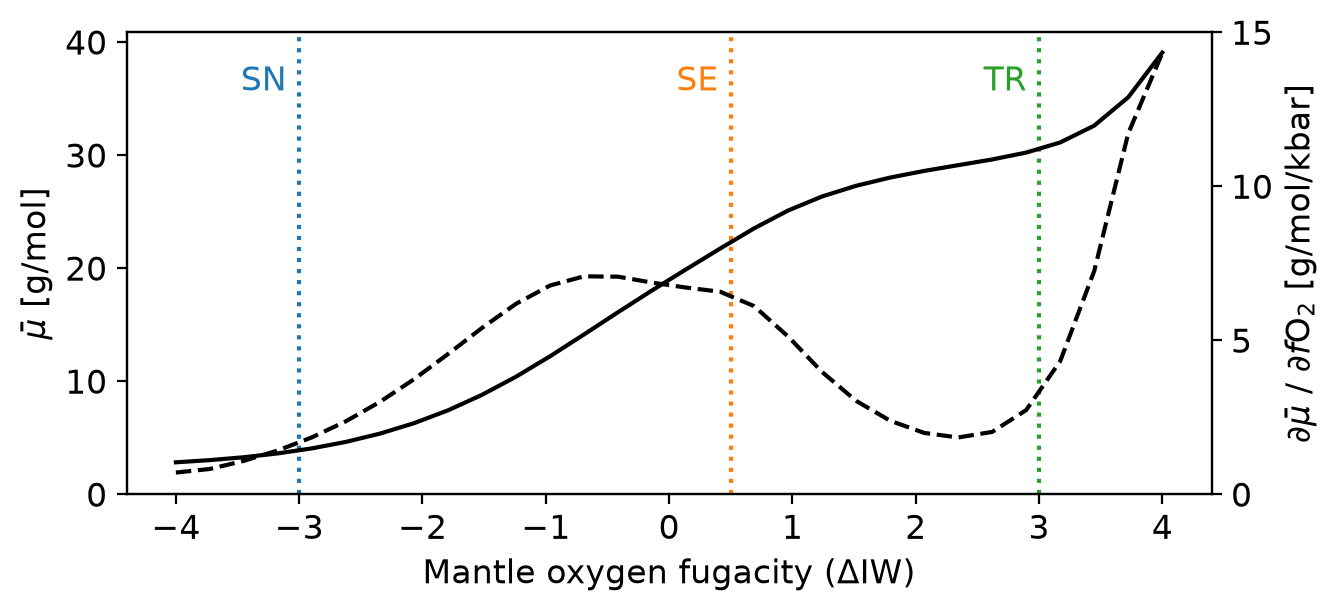

In [10]:
def sens_plot(x_key, x_lbl, x_arr):
    # out keys
    z_out = {}
    for k in [v+"_vmr" for v in solvevol_vols]:
        z_out[k] = []
    for k in [v+"_bar" for v in solvevol_vols]:
        z_out[k] = []
    z_out["atm_kg_per_mol"] = []

    # run model
    x_plt = []
    y_plt_mmw = []
    y_plt_prs = []

    p_guess = None
    for i in range(len(x_arr)):
        # print("%02d/%02d"%(i+1,len(x_arr)))
        x = x_arr[i]

        OPTIONS = deepcopy(BACKUP_options)
        OPTIONS[x_key] = x

        if x_key == "H_ppmw":
            OPTIONS = set_composition(OPTIONS, x)

        solvevol_target = get_target_from_params(OPTIONS)
        p_d = equilibrium_atmosphere(solvevol_target, OPTIONS, opt_solver=False,
                                        p_guess=p_guess,
                                        rtol=1e-5, xtol=1e-5, atol=1e2, nsolve=600)
        for k in z_out.keys():
            z_out[k].append(p_d[k])

        p_guess = {}
        for g in ("H2O","CO2","N2","S2"):
            p_guess[g] = p_d[f"{g}_bar"]

        # plot x: fO2
        x_plt.append(x)

        # plot y: mmw
        y_plt_mmw.append(p_d['atm_kg_per_mol'] * 1e3)
        y_plt_prs.append(p_d['P_surf']/1e3)


    # make plot of mmw and surface pressure vs xkey
    fig, axl = plt.subplots(1, 1, figsize=(7,3))
    axr = axl.twinx()

    axl.axvline(-3.0, color='tab:blue',   ls='dotted', lw=1.5)
    axl.annotate('SN', xy=(-3.1, 35.0), color='tab:blue', fontsize=12, ha='right', va='bottom')

    axl.axvline(+0.5, color='tab:orange', ls='dotted', lw=1.5)
    axl.annotate('SE', xy=(+0.4, 35.0), color='tab:orange', fontsize=12, ha='right', va='bottom')

    axl.axvline(+3.0, color='tab:green',  ls='dotted', lw=1.5)
    axl.annotate('TR', xy=(+2.9, 35.0), color='tab:green', fontsize=12, ha='right', va='bottom')

    c0 = 'k'
    c1 = 'k'

    y_der_mmw = np.gradient(y_plt_mmw, x_plt)

    axl.plot(x_plt, y_plt_mmw, color=c0, label='Mean molecular weight')
    axr.plot(x_plt, y_der_mmw, color=c1, label='Surface pressure', ls='dashed')

    # axl.axhline(y=18.01528, color='b',   ls='dotted', lw=1.5)
    # axl.axhline(y=2.016,   color='r', ls='dotted', lw=1.5)

    axl.set_xlabel(x_lbl)
    axl.set_ylabel(r'$\bar\mu$ [g/mol]', color=c0)
    axr.set_ylabel(r'$\partial \bar\mu$ / $\partial f\mathrm{O_2}$ [g/mol/kbar]', color=c1)
    axl.tick_params(axis='y', labelcolor=c0)
    axr.tick_params(axis='y', labelcolor=c1)
    axl.set_ylim(bottom=0)
    axr.set_ylim(bottom=0)

    axl.set_xticks(np.arange(-4,5,1))
    # axl.grid()

    fig.savefig("output/sensitivity-%s.pdf" % x_key, dpi=300, bbox_inches='tight')

    return y_plt_mmw, y_plt_prs


# parameters
x_key1 = "fO2_shift_IW"
x_lbl1 = r"Mantle oxygen fugacity ($\Delta$IW)"
x_arr1 = np.linspace(-4, 4, 30)
y_arr1_mmw, y_arr1_prs = sens_plot(x_key1, x_lbl1, x_arr1)

print("Done")
